In [2]:
import pandas as pd
import numpy as np

# Load processed training and testing data
X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634, 1)
y_test shape: (1409, 1)


In [3]:
print("Training features:")
display(X_train.head())

print("\nTraining target:")
display(y_train.head())

Training features:


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,49.20,1701.65
1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,75.10,1151.55
2,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,13.0,40.55,590.35
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,26.0,73.50,1905.70
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.55,44.55



Training target:


,Churn
0,0
1,0
2,0
3,0
4,0


In [4]:
print("Feature columns:")
print(X_train.columns.tolist())

Feature columns:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']


In [5]:
print("Target distribution:")
print(y_train.value_counts())

Target distribution:
Churn
0        4139
1        1495
Name: count, dtype: int64


In [6]:
print(y_train.iloc[:, 0].value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


In [7]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5634 non-null   float64
 1   1       5634 non-null   float64
 2   2       5634 non-null   float64
 3   3       5634 non-null   float64
 4   4       5634 non-null   float64
 5   5       5634 non-null   float64
 6   6       5634 non-null   float64
 7   7       5634 non-null   float64
 8   8       5634 non-null   float64
 9   9       5634 non-null   float64
 10  10      5634 non-null   float64
 11  11      5634 non-null   float64
 12  12      5634 non-null   float64
 13  13      5634 non-null   float64
 14  14      5634 non-null   float64
 15  15      5634 non-null   float64
 16  16      5634 non-null   float64
 17  17      5634 non-null   float64
 18  18      5634 non-null   float64
 19  19      5634 non-null   float64
 20  20      5634 non-null   float64
 21  21      5634 non-null   float64
 22  22      563

In [8]:
X_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.502840,0.484381,0.298012,0.900781,0.099219,0.424210,0.440717,0.215477,0.215477,0.288072,...,0.208200,0.241214,0.591232,0.215300,0.335641,0.228257,0.163294,32.485091,64.929961,2299.334682
std,0.500036,0.499800,0.457425,0.298982,0.298982,0.494266,0.496517,0.411190,0.411190,0.452905,...,0.406057,0.427858,0.491650,0.411067,0.472256,0.419746,0.369667,24.568744,30.138105,2279.204278
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.400000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,35.662500,402.975000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,70.500000,1394.925000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,55.000000,90.000000,3835.825000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000


# Customer Churn Prediction Using Machine Learning

## 1. Machine Learning Model Development

In this section, different supervised machine learning classification algorithms are trained and evaluated to predict customer churn.

The models used are:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [10]:
y_train = y_train["Churn"]
y_test = y_test["Churn"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


## 2. Logistic Regression

Logistic Regression is used as a baseline classification model for predicting whether a customer will churn or remain with the company.

In [11]:
logistic_model = LogisticRegression(max_iter=3000)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [12]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.8070
Precision: 0.6614
Recall   : 0.5588
F1 Score : 0.6058
ROC-AUC  : 0.8424


In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[928 107]
 [165 209]]


## 2. Decision Tree Classifier

A Decision Tree is trained to predict customer churn by creating a series of decision rules based on the input features.


In [14]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [15]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("---------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

Decision Tree Results
---------------------
Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC-AUC  : 0.8267


In [16]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[917 118]
 [172 202]]


## 3. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction performance and reduce the limitations of a single decision tree.

In [17]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7970
Precision: 0.6477
Recall   : 0.5160
F1 Score : 0.5744
ROC-AUC  : 0.8253


In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[930 105]
 [181 193]]


## 4. K-Nearest Neighbors (KNN)

K-Nearest Neighbors classifies a customer based on the classes of nearby observations in the feature space.

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

print("KNN trained successfully.")

KNN trained successfully.


In [21]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Results")
print("-----------")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")
print(f"ROC-AUC  : {knn_auc:.4f}")

KNN Results
-----------
Accuracy : 0.7658
Precision: 0.5791
Recall   : 0.4305
F1 Score : 0.4939
ROC-AUC  : 0.7551


In [22]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(cm_knn)

Confusion Matrix:
[[918 117]
 [213 161]]


## 5. Model Performance Comparison

The performance of all four classification algorithms is compared using accuracy, precision, recall, F1-score, and ROC-AUC.

In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        knn_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        knn_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        knn_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc,
        knn_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.661392,0.558824,0.605797,0.842385
1,Decision Tree,0.794180,0.631250,0.540107,0.582133,0.826704
2,Random Forest,0.797019,0.647651,0.516043,0.574405,0.825338
3,KNN,0.765791,0.579137,0.430481,0.493865,0.755056


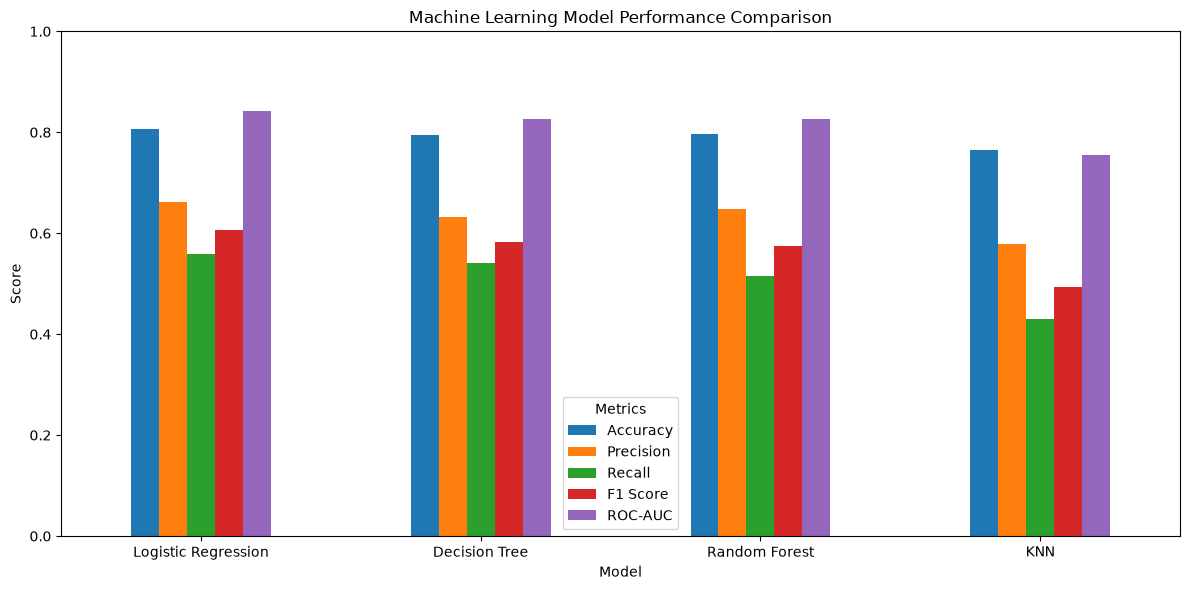

In [24]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

### Model Comparison Analysis

The four classification algorithms were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Logistic Regression achieved the best overall performance, with an accuracy of 80.70% and an ROC-AUC of 0.8424. It also achieved the highest precision, recall, and F1-score among the four models.

Decision Tree achieved an accuracy of 79.42%, while Random Forest achieved 79.70%. Although Random Forest is an ensemble method consisting of multiple decision trees, it did not outperform Logistic Regression on this dataset.

KNN achieved the lowest overall performance, with an accuracy of 76.58% and an ROC-AUC of 0.7551.

Based on the evaluation results, Logistic Regression was selected as the best-performing model for customer churn prediction.

## 6. Confusion Matrix Visualization

Confusion matrices are used to analyze the types of correct and incorrect predictions made by each classification model.

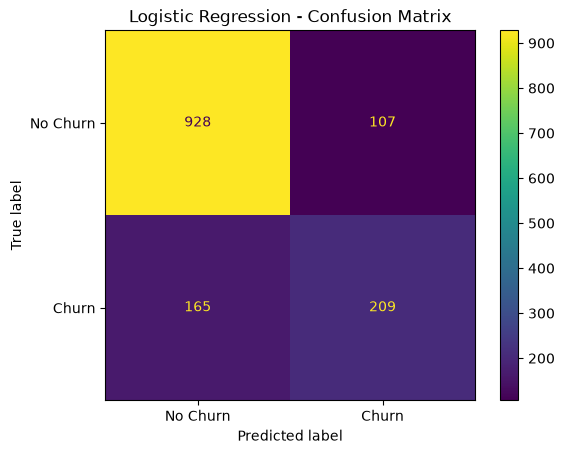

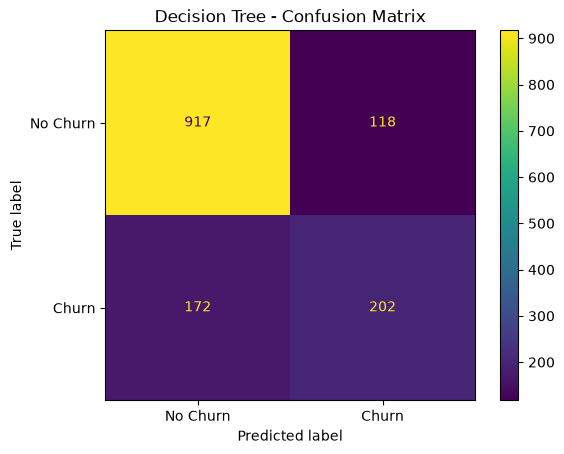

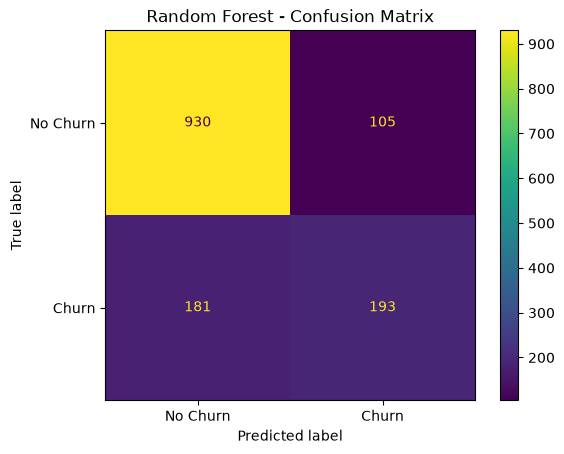

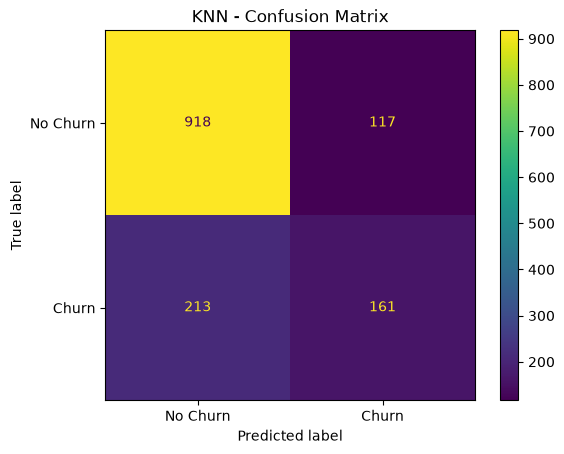

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

## 7. ROC Curve Comparison

The ROC curve evaluates the ability of each model to distinguish between customers who churn and customers who do not churn across different classification thresholds.

A higher ROC-AUC indicates better overall discrimination between the two classes.

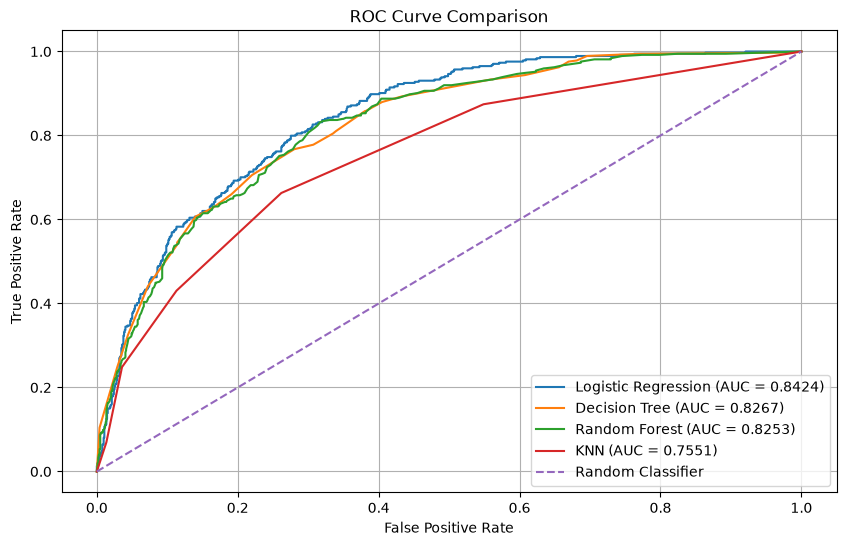

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf,
    "KNN": y_prob_knn
}

plt.figure(figsize=(10, 6))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [27]:
import joblib

preprocessor = joblib.load("../data/processed/preprocessor.pkl")

print(preprocessor)

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num', 'passthrough',
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges'])])


In [28]:
print("Preprocessor type:", type(preprocessor))

Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [29]:
if hasattr(preprocessor, "get_feature_names_out"):
    feature_names = preprocessor.get_feature_names_out()
    print("Number of feature names:", len(feature_names))
    print(feature_names)
else:
    print("This preprocessor does not provide feature names.")

Number of feature names: 30
['cat__gender_Male' 'cat__Partner_Yes' 'cat__Dependents_Yes'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_One year'
 'cat__Contract_Two year' 'cat__PaperlessBilling_Yes'
 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check'
 'num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges']


## 8. Feature Importance Analysis

Feature importance analysis is performed using the coefficients of the Logistic Regression model. Since Logistic Regression assigns a coefficient to each feature, the magnitude of the coefficient indicates the strength of its contribution to the prediction.

Positive coefficients indicate a higher likelihood of churn, while negative coefficients indicate a lower likelihood of churn.

In [30]:
# Get Logistic Regression coefficients
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient value
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
21,cat__Contract_Two year,-1.323080,1.323080
6,cat__InternetService_Fiber optic,1.319390,1.319390
20,cat__Contract_One year,-0.684718,0.684718
19,cat__StreamingMovies_Yes,0.430512,0.430512
17,cat__StreamingTV_Yes,0.429834,0.429834
5,cat__MultipleLines_Yes,0.391729,0.391729
24,cat__PaymentMethod_Electronic check,0.381887,0.381887
22,cat__PaperlessBilling_Yes,0.373263,0.373263
9,cat__OnlineSecurity_Yes,-0.320724,0.320724
4,cat__MultipleLines_No phone service,0.280673,0.280673


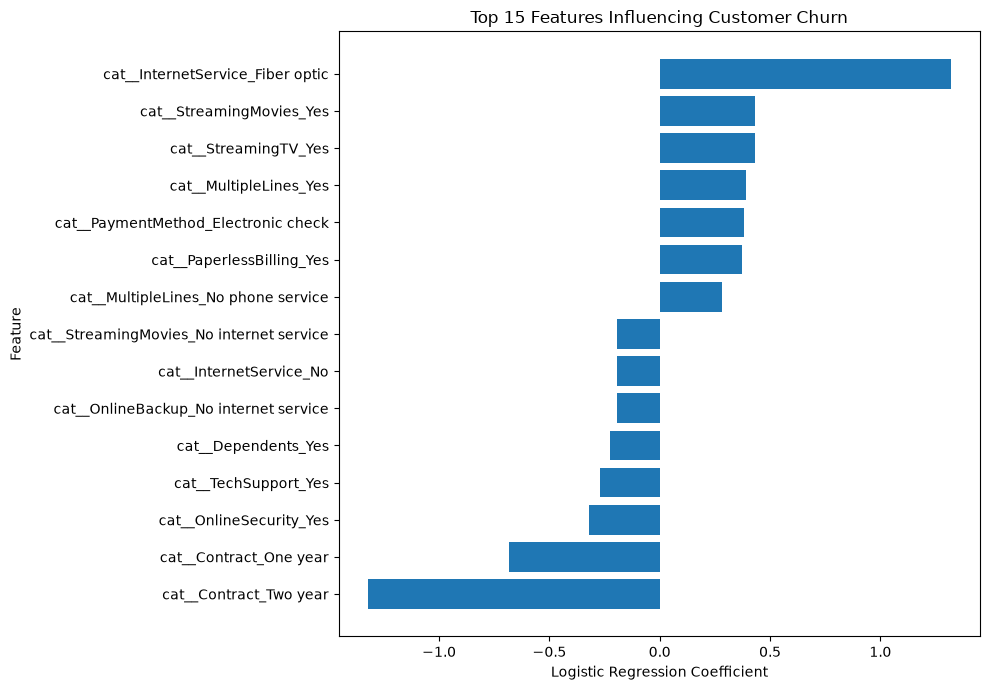

In [31]:
top_features = feature_importance.head(15).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Customer Churn")
plt.tight_layout()
plt.show()

In [32]:
print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Churn", "Churn"]
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 9. Final Model Selection

Based on the evaluation metrics, the models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Logistic Regression was selected as the final model because it achieved the strongest overall performance among the tested models on the given test dataset.

The final model can therefore be used as the baseline predictive model for identifying customers who are likely to churn.

In [33]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.
